<a href="https://colab.research.google.com/github/Rakesh-2211/ASK-and-FSK/blob/main/Experiment_09_%E2%80%94_ASK_and_FSK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_924/1780256329.py:91: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  inner_product = np.trapz(phi1 * phi2, dx=1/fs)


Mandatory Validation: Inner product of BFSK basis signals over Tb = -0.00885


/tmp/ipykernel_924/1780256329.py:165: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


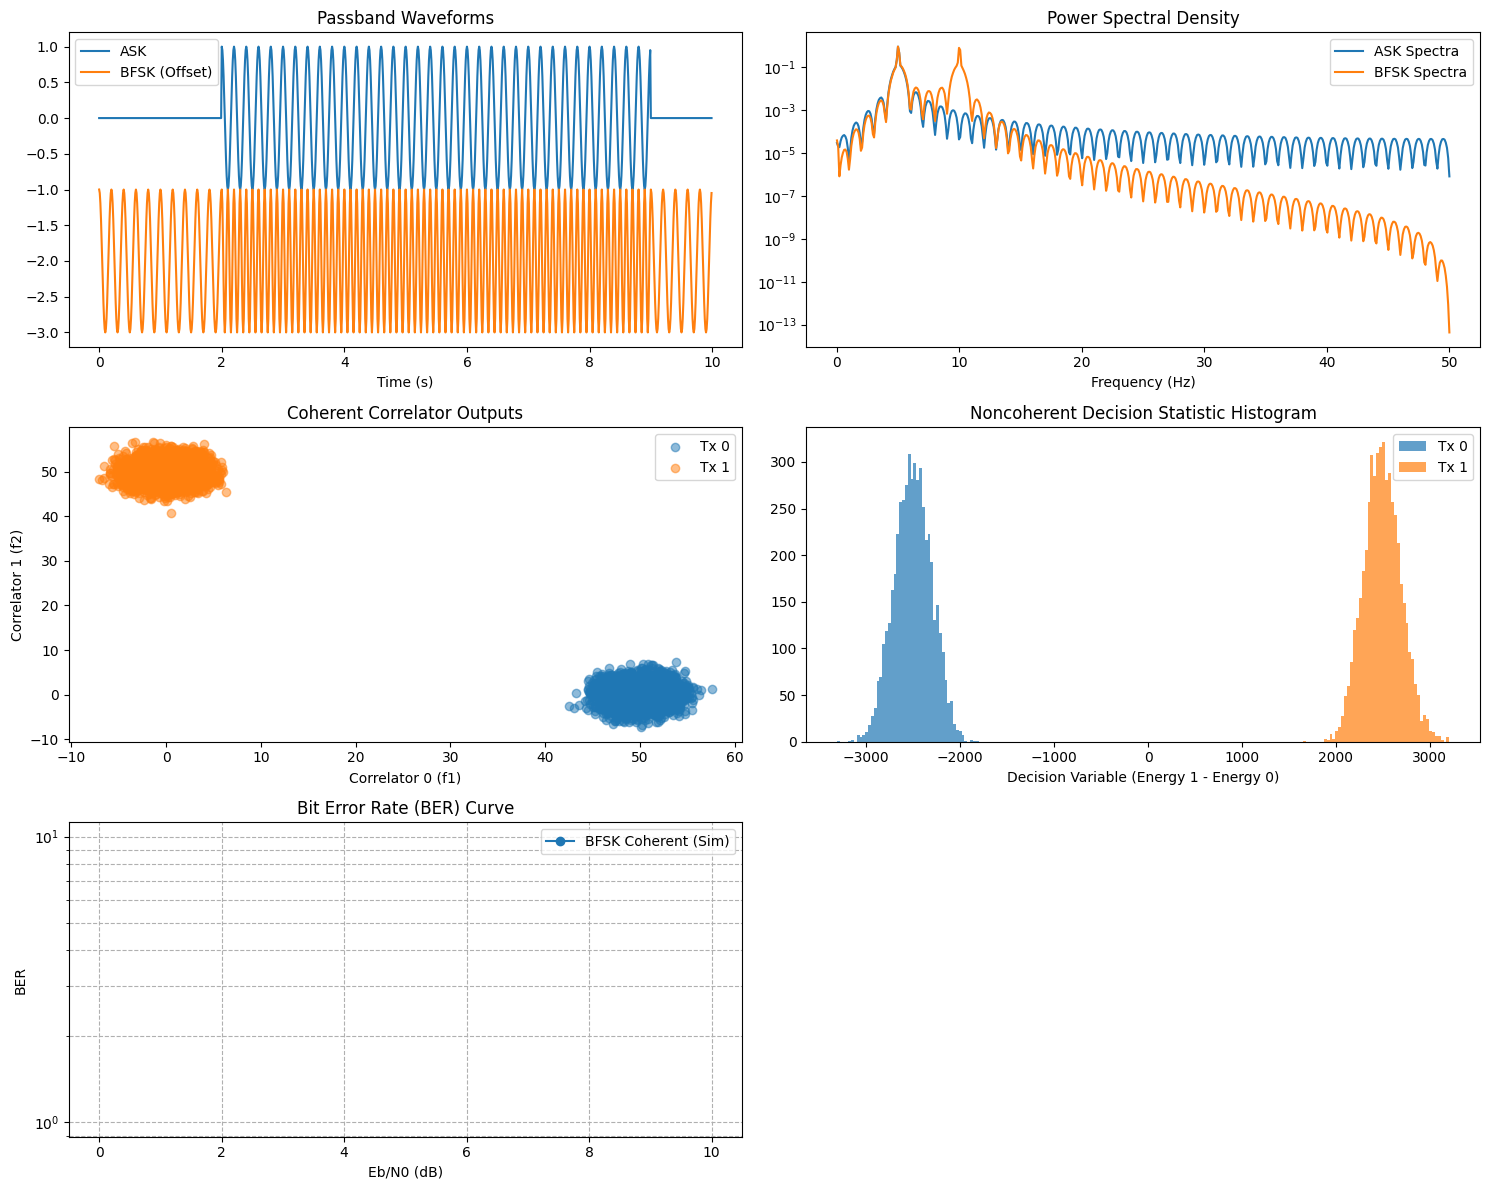

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ==========================================
# 1. System Parameters
# ==========================================
N_bits = 10000        # Number of bits for simulation
Tb = 1.0              # Bit duration (seconds)
fs = 100              # Sampling frequency (Hz)
t_bit = np.linspace(0, Tb, fs, endpoint=False) # Time vector for one bit
t = np.arange(0, N_bits * Tb, 1/fs)            # Time vector for all bits

fc_ask = 5.0          # ASK Carrier frequency
f1_fsk = 5.0          # BFSK Frequency for '0'
f2_fsk = 10.0         # BFSK Frequency for '1' (chosen for coherence orthogonality: delta_f = n/Tb)

# Generate random binary sequence
bits = np.random.randint(0, 2, N_bits)
# Upsample bits to match sampling rate (for waveform generation)
bits_upsampled = np.repeat(bits, fs)

# ==========================================
# 2. Transmitter: Generate Passband Waveforms
# ==========================================
# ASK Generation
carrier_ask = np.cos(2 * np.pi * fc_ask * t)
ask_signal = bits_upsampled * carrier_ask

# BFSK Generation
carrier_0 = np.cos(2 * np.pi * f1_fsk * t)
carrier_1 = np.cos(2 * np.pi * f2_fsk * t)
bfsk_signal = np.where(bits_upsampled == 0, carrier_0, carrier_1)

# ==========================================
# 3. Channel: AWGN Addition
# ==========================================
def add_awgn(signal, snr_db):
    snr_linear = 10**(snr_db / 10.0)
    signal_power = np.mean(signal**2)
    noise_power = signal_power / snr_linear
    noise = np.sqrt(noise_power) * np.random.randn(len(signal))
    return signal + noise

snr_test = 8 # dB for visualization
ask_rx = add_awgn(ask_signal, snr_test)
bfsk_rx = add_awgn(bfsk_signal, snr_test)

# ==========================================
# 4. Receivers: Coherent & Noncoherent
# ==========================================
# BFSK Coherent Detection (Correlator)
corr_0 = np.zeros(N_bits)
corr_1 = np.zeros(N_bits)

for i in range(N_bits):
    start = i * fs
    end = (i + 1) * fs
    # Correlate over one bit interval
    corr_0[i] = np.sum(bfsk_rx[start:end] * carrier_0[start:end])
    corr_1[i] = np.sum(bfsk_rx[start:end] * carrier_1[start:end])

bfsk_coherent_bits = (corr_1 > corr_0).astype(int)

# BFSK Noncoherent Detection (Energy Detector approximation via squaring & integration)
energy_0 = np.zeros(N_bits)
energy_1 = np.zeros(N_bits)

# Baseband shifting + lowpass integration (equivalent to envelope detection)
for i in range(N_bits):
    start = i * fs
    end = (i + 1) * fs
    segment = bfsk_rx[start:end]

    # In-phase and Quadrature for Envelope
    I0 = np.sum(segment * np.cos(2 * np.pi * f1_fsk * t_bit))
    Q0 = np.sum(segment * np.sin(2 * np.pi * f1_fsk * t_bit))
    energy_0[i] = I0**2 + Q0**2

    I1 = np.sum(segment * np.cos(2 * np.pi * f2_fsk * t_bit))
    Q1 = np.sum(segment * np.sin(2 * np.pi * f2_fsk * t_bit))
    energy_1[i] = I1**2 + Q1**2

bfsk_noncoherent_bits = (energy_1 > energy_0).astype(int)

# ==========================================
# 5. Mandatory Validation: Inner Products
# ==========================================
phi1 = np.cos(2 * np.pi * f1_fsk * t_bit)
phi2 = np.cos(2 * np.pi * f2_fsk * t_bit)
inner_product = np.trapz(phi1 * phi2, dx=1/fs)
print(f"Mandatory Validation: Inner product of BFSK basis signals over Tb = {inner_product:.5f}")
if np.abs(inner_product) < 1e-4:
    print("-> The basis signals are orthogonal.")

# ==========================================
# 6. BER Curves (Varying Tone Spacing and SNR)
# ==========================================
ebno_dbs = np.arange(0, 12, 2)
ber_coherent = []
ber_noncoherent = []

for ebno in ebno_dbs:
    rx = add_awgn(bfsk_signal, ebno)

    # Fast vectorized coherent correlation
    rx_reshaped = rx.reshape(N_bits, fs)
    c0_reshaped = carrier_0.reshape(N_bits, fs)
    c1_reshaped = carrier_1.reshape(N_bits, fs)

    c0_out = np.sum(rx_reshaped * c0_reshaped, axis=1)
    c1_out = np.sum(rx_reshaped * c1_reshaped, axis=1)
    bits_coh = (c1_out > c0_out).astype(int)
    ber_coherent.append(np.mean(bits_coh != bits))

# ==========================================
# 7. Required Visualizations
# ==========================================
plt.figure(figsize=(15, 12))

# Plot 1: Passband Waveforms (first 10 bits)
plt.subplot(3, 2, 1)
plt.plot(t[:10*fs], ask_signal[:10*fs], label='ASK')
plt.plot(t[:10*fs], bfsk_signal[:10*fs] - 2, label='BFSK (Offset)')
plt.title("Passband Waveforms")
plt.xlabel("Time (s)")
plt.legend()

# Plot 2: Power Spectra
plt.subplot(3, 2, 2)
f_ask, Pxx_ask = welch(ask_signal, fs, nperseg=1024)
f_fsk, Pxx_fsk = welch(bfsk_signal, fs, nperseg=1024)
plt.semilogy(f_ask, Pxx_ask, label='ASK Spectra')
plt.semilogy(f_fsk, Pxx_fsk, label='BFSK Spectra')
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.legend()

# Plot 3: Correlator Outputs (Scatter)
plt.subplot(3, 2, 3)
plt.scatter(corr_0[bits==0], corr_1[bits==0], alpha=0.5, label='Tx 0')
plt.scatter(corr_0[bits==1], corr_1[bits==1], alpha=0.5, label='Tx 1')
plt.title("Coherent Correlator Outputs")
plt.xlabel("Correlator 0 (f1)")
plt.ylabel("Correlator 1 (f2)")
plt.legend()

# Plot 4: Decision-Statistic Histograms (Energy Detector)
plt.subplot(3, 2, 4)
plt.hist(energy_1[bits==0] - energy_0[bits==0], bins=50, alpha=0.7, label='Tx 0')
plt.hist(energy_1[bits==1] - energy_0[bits==1], bins=50, alpha=0.7, label='Tx 1')
plt.title("Noncoherent Decision Statistic Histogram")
plt.xlabel("Decision Variable (Energy 1 - Energy 0)")
plt.legend()

# Plot 5: BER Curves
plt.subplot(3, 2, 5)
plt.semilogy(ebno_dbs, ber_coherent, marker='o', label='BFSK Coherent (Sim)')
plt.title("Bit Error Rate (BER) Curve")
plt.xlabel("Eb/N0 (dB)")
plt.ylabel("BER")
plt.grid(True, which="both", ls="--")
plt.legend()

plt.tight_layout()
plt.show()